In [9]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from datetime import datetime
import talib as ta
from scipy.signal import find_peaks

In [10]:
df = pd.read_json('nifty-dataset.json')
df = df[['date', 'open', 'high', 'low', 'close', 'volume']].reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])


In [ ]:
def rw_top(data: np.array, curr_index: int, order: int) -> bool:
    if curr_index < order * 2 + 1:
        return False

    top = True
    k = curr_index - order
    v = data[k]
    for i in range(1, order + 1):
        if data[k + i] > v or data[k - i] > v:
            top = False
            break

    return top

# Checks if there is a local top detected at curr index
def rw_bottom(data: np.array, curr_index: int, order: int) -> bool:
    if curr_index < order * 2 + 1:
        return False

    bottom = True
    k = curr_index - order
    v = data[k]
    for i in range(1, order + 1):
        if data[k + i] < v or data[k - i] < v:
            bottom = False
            break

    return bottom

def rw_extremes(data: np.array, order:int):
    # Rolling window local tops and bottoms
    tops = []
    bottoms = []
    for i in range(len(data)):
        if rw_top(data, i, order):
            # top[0] = confirmation index
            # top[1] = index of top
            # top[2] = price of top
            top = [i, i - order, data[i - order]]
            tops.append(top)

        if rw_bottom(data, i, order):
            # bottom[0] = confirmation index
            # bottom[1] = index of bottom
            # bottom[2] = price of bottom
            bottom = [i, i - order, data[i - order]]
            bottoms.append(bottom)

    return tops, bottoms

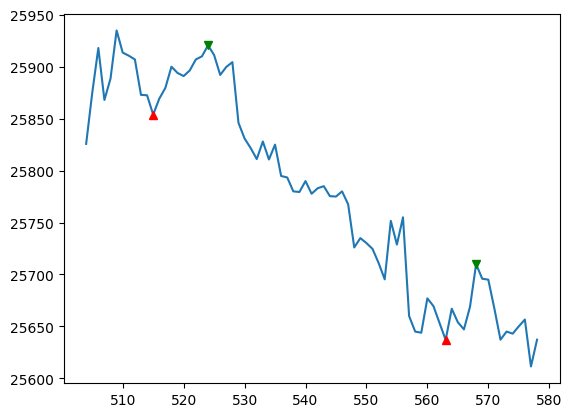

<Figure size 1800x400 with 0 Axes>

In [25]:
data = df[-75:]

tops, bottoms = rw_extremes(data['close'].to_numpy(), 10)
data['close'].plot()
idx = data.index
for top in tops:
    plt.plot(idx[top[1]], top[2], marker='v', color='green')

for bottom in bottoms:
    plt.plot(idx[bottom[1]], bottom[2], marker='^', color='red')

plt.figure(figsize=(18, 4))
plt.show()
